In [7]:
%matplotlib qt

import numpy as np
from scipy.special import softmax, expit
from pickle import load
import sys
from matplotlib import pyplot as plt
import json

def read_pkl_alphafold_3(pkl_file):
    _CONTACT_THRESHOLD = 8.0
    _CONTACT_EPSILON = 1e-3
    """
    Reads the distograms pkl file outputed from Alphafold and returns the bins (63) and distograms (NxNx64)
    """
    with open(pkl_file, "rb") as f:
        data_first = load(f)
        print(data_first.keys())

    with open('1bml-2_confidences.json', 'r') as file:
        data_json = json.load(file)
        print(data_json.keys())

    #print(data_first['probs'].shape)
    
    data = data_first['distogram']
    # Bins -> distance axis: initially 64 bins from 2 to 22 but the last one covers also above 22.
    # 20/64 = 0.3125 = delta_bins. first bin (2.3125) covers 2 to 2.3125. 
    # center of it is therefore 2.3125 - delta_bins/2
    bins = data['bin_edges']

    bin_tops = np.append(bins, bins[-1] + (bins[-1] - bins[-2]))
    threshold = _CONTACT_THRESHOLD + _CONTACT_EPSILON
    is_contact_bin = 1.0 * (bin_tops <= threshold)
    contact_probs_pred = np.einsum('ijk,k->ij', data['softmax'], is_contact_bin)

    print(bins)
    delta_bins = bins[1]-bins[0]
    # Shift the bins such that the distribution data point are assumed in the center of the bin:
    # (And converting the bin values from Angstrom to nm)
    #bins = [(el-(delta_bins/2))*0.1 for el in bins]
    bins = (bins - (delta_bins/2))*0.1
    distograms = data['softmax']
    print(distograms.shape)

    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(data_json['contact_probs'], cmap="RdYlBu_r")
    ax[1].imshow(contact_probs_pred, cmap="RdYlBu_r")

    return bins, distograms

out = read_pkl_alphafold_3('1bml-2_confidences.pkl')

dict_keys(['distogram'])
dict_keys(['atom_chain_ids', 'atom_plddts', 'contact_probs', 'probs', 'bin_edges', 'pae', 'token_chain_ids', 'token_res_ids'])
[ 2.3125    2.625     2.9375    3.25      3.5625    3.875     4.1875
  4.5       4.8125    5.125     5.4375    5.75      6.0625    6.375
  6.6875    7.        7.3125    7.625     7.9375    8.25      8.5625
  8.875     9.1875    9.5       9.812499 10.125    10.4375   10.75
 11.0625   11.375    11.6875   12.       12.3125   12.625    12.9375
 13.25     13.5625   13.875    14.1875   14.499999 14.8125   15.125
 15.4375   15.75     16.0625   16.375    16.6875   16.999998 17.312498
 17.625    17.9375   18.25     18.5625   18.875    19.1875   19.5
 19.8125   20.125    20.437498 20.75     21.0625   21.375    21.6875  ]
(1250, 1250, 64)


[ 2.3125    2.625     2.9375    3.25      3.5625    3.875     4.1875
  4.5       4.8125    5.125     5.4375    5.75      6.0625    6.375
  6.6875    7.        7.3125    7.625     7.9375    8.25      8.5625
  8.875     9.1875    9.5       9.812499 10.125    10.4375   10.75
 11.0625   11.375    11.6875   12.       12.3125   12.625    12.9375
 13.25     13.5625   13.875    14.1875   14.499999 14.8125   15.125
 15.4375   15.75     16.0625   16.375    16.6875   16.999998 17.312498
 17.625    17.9375   18.25     18.5625   18.875    19.1875   19.5
 19.8125   20.125    20.437498 20.75     21.0625   21.375    21.6875  ]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
(1250, 1250, 64)
1.0
(1250, 1250)


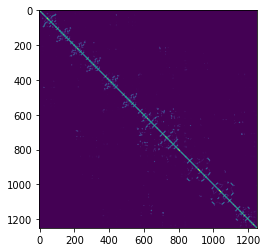

In [2]:
import numpy as np
from scipy.special import softmax, expit
from pickle import load
import sys
import matplotlib.pyplot as plt

def read_pkl_alphafold_2(pkl_file, convf="softmax"):

    threshold = 8.0  # Å
    """
    Reads the distograms pkl file outputed from Alphafold and returns the bins (63) and distograms (NxNx64)
    """
    with open(pkl_file, "rb") as f:
        data = load(f)['distogram']
    # Bins -> distance axis: initially 64 bins from 2 to 22 but the last one covers also above 22.
    # 20/64 = 0.3125 = delta_bins. first bin (2.3125) covers 2 to 2.3125. 
    # center of it is therefore 2.3125 - delta_bins/2
    bins = data['bin_edges']
    contact_bin = np.where(bins < threshold)[0]
    print(bins)
    print(contact_bin)
    delta_bins = bins[1]-bins[0]
    # Shift the bins such that the distribution data point are assumed in the center of the bin:
    # (And converting the bin values from Angstrom to nm)
    bins = [(el-(delta_bins/2))*0.1 for el in bins]
    distograms = data['logits']
    print(distograms.shape)
    # Remove last bin since it is the above 22 Angstrom garbage ([:-1])
    # And apply conversion to probability distribution function to obtain the distribution:
    # distograms = np.array([[softmax(ell[:]) for ell in el] for el in distograms])
    if convf == "softmax":
        distograms = np.array([[softmax(ell[:]) for ell in el] for el in distograms])
    elif convf == "sigmoid":
        distograms = np.array([[expit(ell[:]) for ell in el] for el in distograms])
        distograms = np.array([[ell[:]/np.sum(ell) for ell in el] for el in distograms])
    else:
        print("conversion function not recognized. Please select softmax (default) or sigmoid.")
        sys.exit(1)
    
    print(distograms[0, 0].sum())

    contact_map = distograms[..., contact_bin].sum(axis=-1)
    print(contact_map.shape)

    plt.imshow(contact_map)

    return bins, distograms

out = read_pkl_alphafold_2('1bml-2_confidences.pkl')

In [2]:
import json

with open('6d03__b1_p02786--6d03__e1_a5k736_confidences.json') as f:
    d = json.load(f)
    print(d.keys())
    print(d['contact_probs'].dtype)

dict_keys(['atom_chain_ids', 'atom_plddts', 'contact_probs', 'probs', 'bin_edges', 'pae', 'token_chain_ids', 'token_res_ids'])


AttributeError: 'list' object has no attribute 'dtype'

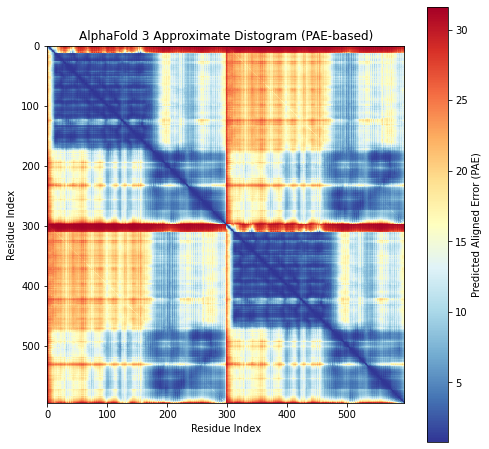

In [10]:
plt.figure(figsize=(8, 8))
plt.imshow(pae_matrix, cmap="RdYlBu_r", interpolation="none")
plt.colorbar(label="Predicted Aligned Error (PAE)")
plt.title("AlphaFold 3 Approximate Distogram (PAE-based)")
plt.xlabel("Residue Index")
plt.ylabel("Residue Index")
plt.show()